In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile("archive (1).zip", 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
import os
print(os.listdir())

['.config', 'True.csv', 'Fake.csv', 'archive (1).zip', 'sample_data']


In [ ]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

In [ ]:
fake["label"] = 0
true["label"] = 1

In [ ]:
data = pd.concat([fake, true])

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data["text"] = data["text"].apply(clean_text)

In [ ]:
# Balance dataset
fake_data = data[data["label"] == 0]
real_data = data[data["label"] == 1]

real_data = real_data.sample(len(fake_data), random_state=42)

data = pd.concat([fake_data, real_data])
data = data.sample(frac=1, random_state=42)

In [ ]:
X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [ ]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
}

results = {}

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name} Results:")
    print("Accuracy:", acc)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


Naive Bayes Results:
Accuracy: 0.9327394209354121

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94      4710
           1       0.93      0.93      0.93      4270

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980


Logistic Regression Results:
Accuracy: 0.9826280623608018

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      4710
           1       0.98      0.98      0.98      4270

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



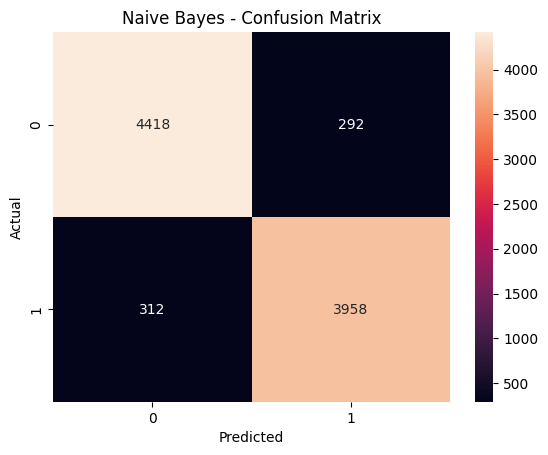

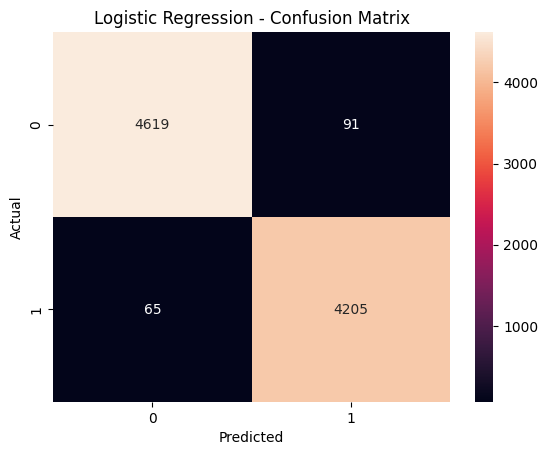

In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

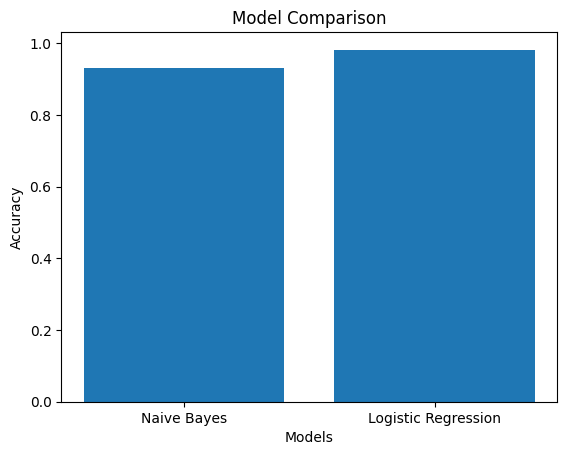

In [ ]:
model_names = list(results.keys())
accuracies = list(results.values())

plt.figure()
plt.bar(model_names, accuracies)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9327394209354121

Confusion Matrix:
 [[4418  292]
 [ 312 3958]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.94      4710
           1       0.93      0.93      0.93      4270

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980



In [ ]:
def predict_news(text):
    text = clean_text(text)
    text_vec = vectorizer.transform([text])
    result = model.predict(text_vec)
    if result[0] == 1:
        return "Real News"
    else:
        return "Fake News"

In [ ]:
print(predict_news("India successfully launched a new communication satellite to improve internet connectivity in rural areas."))

print(predict_news("Aliens are secretly controlling the government using invisible technology."))

Real News
Fake News


In [ ]:
print(predict_news("Scientists have discovered a secret underground city beneath Antarctica where an advanced alien civilization has been living for thousands of years, according to leaked documents that governments are trying to hide."))

Fake News


In [ ]:
print(predict_news("The Supreme Court issued a landmark judgment regarding privacy rights, stating that citizens' digital data must be protected under constitutional law. The ruling has been widely welcomed by legal experts."))

Real News


NameError: name 'predict_news' is not defined

In [3]:
print(predict_news("The Supreme Court issued a landmark judgment regarding privacy rights, stating that citizens' digital data must be protected under constitutional law. The ruling has been widely welcomed by legal experts."))

NameError: name 'predict_news' is not defined